In [18]:
#import necessary modules
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import geopandas as gpd
import contextily as ctx
pd.set_option('display.max_columns', None)


In [6]:
# load the data
fish_data = pd.read_csv('Larvae.csv')
# convert into dataframe
fish_df = pd.DataFrame(fish_data)
# display the first few rows of the data
fish_df.head()

,cruise,ship,ship_code,order_occupied,tow_type,tow_number,net_location,time,latitude,longitude,line,station,standard_haul_factor,volume_sampled,proportion_sorted,scientific_name,common_name,itis_tsn,calcofi_species_code,larvae_count,larvae_10m2,larvae_100m3
0,195101,SCOFIELD,47,1,C1,1,S,1951-01-19T07:25:00Z,33.833333,-118.625,86.7,35.0,1.65,892.6,1.0,Citharichthys,Sanddabs,172715,924,2.0,3.30,NaN
1,195101,SCOFIELD,47,1,C1,1,S,1951-01-19T07:25:00Z,33.833333,-118.625,86.7,35.0,1.65,892.6,1.0,Engraulis mordax,Northern anchovy,161828,31,103.0,169.95,NaN
2,195101,SCOFIELD,47,1,C1,1,S,1951-01-19T07:25:00Z,33.833333,-118.625,86.7,35.0,1.65,892.6,1.0,Gobiidae,Gobies,171746,795,1.0,1.65,NaN
3,195101,SCOFIELD,47,1,C1,1,S,1951-01-19T07:25:00Z,33.833333,-118.625,86.7,35.0,1.65,892.6,1.0,Leuroglossus stilbius,California smoothtongue,162096,72,134.0,221.10,NaN
4,195101,SCOFIELD,47,1,C1,1,S,1951-01-19T07:25:00Z,33.833333,-118.625,86.7,35.0,1.65,892.6,1.0,Lipolagus ochotensis,Popeye blacksmelt,623625,68,1.0,1.65,NaN


Overview of columns in the data
===================================
| Column Name | Description | Interpretation / Units |
| :--- | :--- | :--- |
| **cruise** | Expedition identifier | Formatted as `YYYYMM` (Year and Month). Identifies the specific quarterly research cruise. |
| **ship** | Research vessel name | The full name of the ship used for the tow (e.g., "New Horizon", "David Starr Jordan"). |
| **ship_code** | Short-hand vessel ID | A unique NOAA/NODC alphanumeric code assigned to the research vessel. |
| **order_occupied** | Station sequence | The sequential order in which stations were visited during that specific cruise. |
| **tow_type** | Sampling method | Method of net deployment: **Oblique** (angled from depth to surface), **Vertical** (straight up), or **Surface** (Manta nets). |
| **tow_number** | Event ID | The specific ID number of the net tow at that station. |
| **net_location** | Net position | For multi-net arrays (like Bongo nets), this indicates if the sample came from the Port (P) or Starboard (S) net. |
| **time** | Timestamp | The date and time (UTC) when the tow was initiated. |
| **latitude** | Geographic Latitude | Decimal degrees (North); positive values represent the California Current region. |
| **longitude** | Geographic Longitude | Decimal degrees (West); usually represented as negative numbers in ERDDAP. |
| **line** | CalCOFI Line | The planned transect line number (perpendicular to the coast). |
| **station** | CalCOFI Station | The planned station number along the line (increasing values move further offshore). |
| **standard_haul_factor** | Calculation constant | A multiplier used to convert the raw count into a "per unit area" value (e.g., per 10m²). |
| **volume_sampled** | Water volume | The total cubic meters ($m^3$) of water filtered through the net, measured by a flowmeter. |
| **proportion_sorted** | Sub-sampling ratio | The fraction of the total sample that was actually sorted for larvae (1.0 = 100% sorted). |
| **scientific_name** | Taxon name | The formal Latin name of the fish larvae species identified. |
| **common_name** | Vernacular name | The common English name for the fish species (e.g., "Pacific Sardine"). |
| **itis_tsn** | Taxonomic Serial Number | The unique ID from the *Integrated Taxonomic Information System* for precise species tracking. |
| **calcofi_species_code** | Internal ID | The legacy 3-digit numeric code used by the CalCOFI program to categorize species. |
| **larvae_count** | Raw abundance | The actual number of individual larvae counted in the sorted portion of the sample. |
| **larvae_10m2** | Standardized abundance | The estimated number of larvae under 10 square meters of sea surface. (Calculated using the `standard_haul_factor`). |
| **larvae_100m3** | Volumetric abundance | The estimated number of larvae per 100 cubic meters of water strained. |

In [7]:
# show number of rows and columns in the data
# fish_df.shape         # should see 385733 rows, 22 columns

# show total number of unique species in the data via common_name
# fish_df['common_name'].nunique()         # 651 unique species in the data

# list of all the column names
# fish_df.columns

# show percentage of missing values in the larvae_100m3 column
# fish_df['larvae_100m3'].isnull().mean() * 100         # over 93% of the values 
                                                        #in this column are missing

# see number of times 924 appears in the calcofi_species_code column
# fish_df['calcofi_species_code'].value_counts()[924]

# see number of missing values in common_name column
# fish_df['common_name'].isnull().sum() 
# see number of missing values in scientific_name column
# fish_df['scientific_name'].isnull().sum()        
# so scientific name has 0 missing but common name has quite a few

/var/folders/0y/mmp_lnms4tx1tvdz0cwsqdx40000gs/T/ipykernel_60493/2328733304.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  species_924_df['time'] = pd.to_datetime(species_924_df['time'])
/var/folders/0y/mmp_lnms4tx1tvdz0cwsqdx40000gs/T/ipykernel_60493/2328733304.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  species_924_df['year'] = species_924_df['time'].dt.year


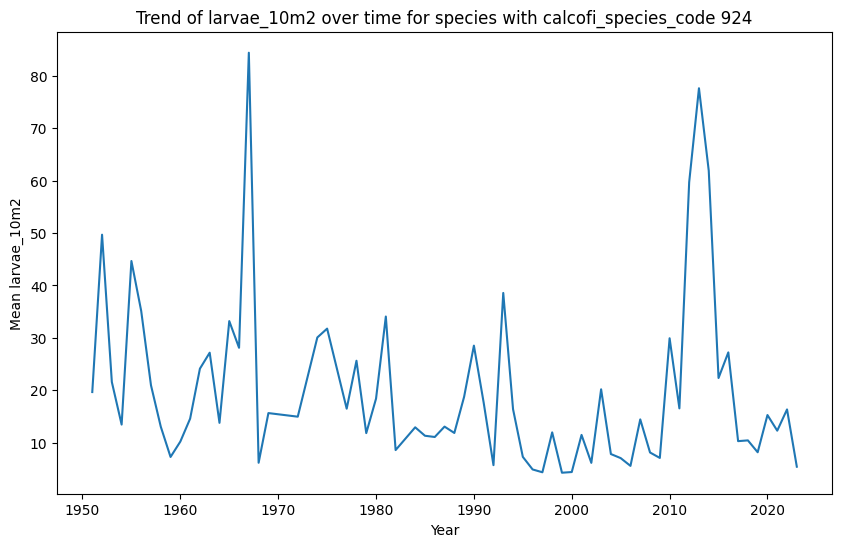

In [8]:
# show trend of larvae_10m2 column over time for the species with calcofi_species_code 924
# filter the data for the species with calcofi_species_code 924
species_924_df = fish_df[fish_df['calcofi_species_code'] == 924]

# group the data by year and calculate the mean of larvae_10m2 for each year, need to first convert time column to datetime format and extract the year
species_924_df['time'] = pd.to_datetime(species_924_df['time'])
species_924_df['year'] = species_924_df['time'].dt.year
yearly_trend_924 = species_924_df.groupby('year')['larvae_10m2'].mean()

# plot the trend over time
plt.figure(figsize=(10, 6))
sns.lineplot(x=yearly_trend_924.index, y=yearly_trend_924.values)
plt.title('Trend of larvae_10m2 over time for species with calcofi_species_code 924')
plt.xlabel('Year')
plt.ylabel('Mean larvae_10m2')
plt.show()

In [9]:
import pandas as pd
import numpy as np

# 1. TEMPORAL CLEANING: Extracting standard time formats
# Convert 'time' to datetime, coercing errors to NaT (Not a Time)
fish_df['time'] = pd.to_datetime(fish_df['time'], errors='coerce')

# Extract 'year' and 'month' for easy decades/seasonal grouping
fish_df['year'] = fish_df['time'].dt.year
fish_df['month'] = fish_df['time'].dt.month

# 2. FIXING THE DENSITY NaNs: Recalculating missing metrics
# Step A: Estimate the total larvae in the net (handling zeroes to avoid division errors)
# If proportion_sorted is 0 or NaN, we'll replace it temporarily with 1 to avoid inf values
safe_proportion = fish_df['proportion_sorted'].replace({0: np.nan}).fillna(1)
estimated_total_larvae = fish_df['larvae_count'] / safe_proportion

# Step B: Recalculate larvae_100m3 (per 100 cubic meters)
# Formula: (Total Larvae / Volume Sampled) * 100
safe_volume = fish_df['volume_sampled'].replace({0: np.nan}) # Prevent division by zero
calculated_100m3 = (estimated_total_larvae / safe_volume) * 100

# Step C: Recalculate larvae_10m2 (per 10 square meters of sea surface)
# Formula: Total Larvae * Standard Haul Factor
calculated_10m2 = estimated_total_larvae * fish_df['standard_haul_factor']

# Step D: Fill the NaNs in the original columns with our calculated values
fish_df['larvae_100m3'] = fish_df['larvae_100m3'].fillna(calculated_100m3)
fish_df['larvae_10m2'] = fish_df['larvae_10m2'].fillna(calculated_10m2)

# Clean up infinite values created by any weird data quirks
fish_df.replace([np.inf, -np.inf], np.nan, inplace=True)

# 3. SPATIAL CLEANING: Prepping for mapping/visualization
# Drop rows that don't have valid coordinates
fish_df = fish_df.dropna(subset=['latitude', 'longitude'])

# 4. TAXONOMIC CLEANING: Handling missing names
# If common_name is missing, fill it with the scientific_name
fish_df['common_name'] = fish_df['common_name'].fillna(fish_df['scientific_name'])
# If both are missing, label as 'Unidentified'
fish_df['common_name'] = fish_df['common_name'].fillna('Unidentified')
fish_df['scientific_name'] = fish_df['scientific_name'].fillna('Unidentified')

# 5. FINAL CHECK 
print("Data Cleaning Complete.")
print(f"Remaining rows: {len(fish_df)}")
print(f"Percentage of missing 'larvae_100m3' values: {fish_df['larvae_100m3'].isna().mean() * 100:.2f}%")

# Display the first few rows of the cleaned data
display(fish_df.head())

Data Cleaning Complete.
Remaining rows: 385733
Percentage of missing 'larvae_100m3' values: 0.00%


,cruise,ship,ship_code,order_occupied,tow_type,tow_number,net_location,time,latitude,longitude,line,station,standard_haul_factor,volume_sampled,proportion_sorted,scientific_name,common_name,itis_tsn,calcofi_species_code,larvae_count,larvae_10m2,larvae_100m3,year,month
0,195101,SCOFIELD,47,1,C1,1,S,1951-01-19 07:25:00+00:00,33.833333,-118.625,86.7,35.0,1.65,892.6,1.0,Citharichthys,Sanddabs,172715,924,2.0,3.30,0.224065,1951,1
1,195101,SCOFIELD,47,1,C1,1,S,1951-01-19 07:25:00+00:00,33.833333,-118.625,86.7,35.0,1.65,892.6,1.0,Engraulis mordax,Northern anchovy,161828,31,103.0,169.95,11.539323,1951,1
2,195101,SCOFIELD,47,1,C1,1,S,1951-01-19 07:25:00+00:00,33.833333,-118.625,86.7,35.0,1.65,892.6,1.0,Gobiidae,Gobies,171746,795,1.0,1.65,0.112032,1951,1
3,195101,SCOFIELD,47,1,C1,1,S,1951-01-19 07:25:00+00:00,33.833333,-118.625,86.7,35.0,1.65,892.6,1.0,Leuroglossus stilbius,California smoothtongue,162096,72,134.0,221.10,15.012324,1951,1
4,195101,SCOFIELD,47,1,C1,1,S,1951-01-19 07:25:00+00:00,33.833333,-118.625,86.7,35.0,1.65,892.6,1.0,Lipolagus ochotensis,Popeye blacksmelt,623625,68,1.0,1.65,0.112032,1951,1


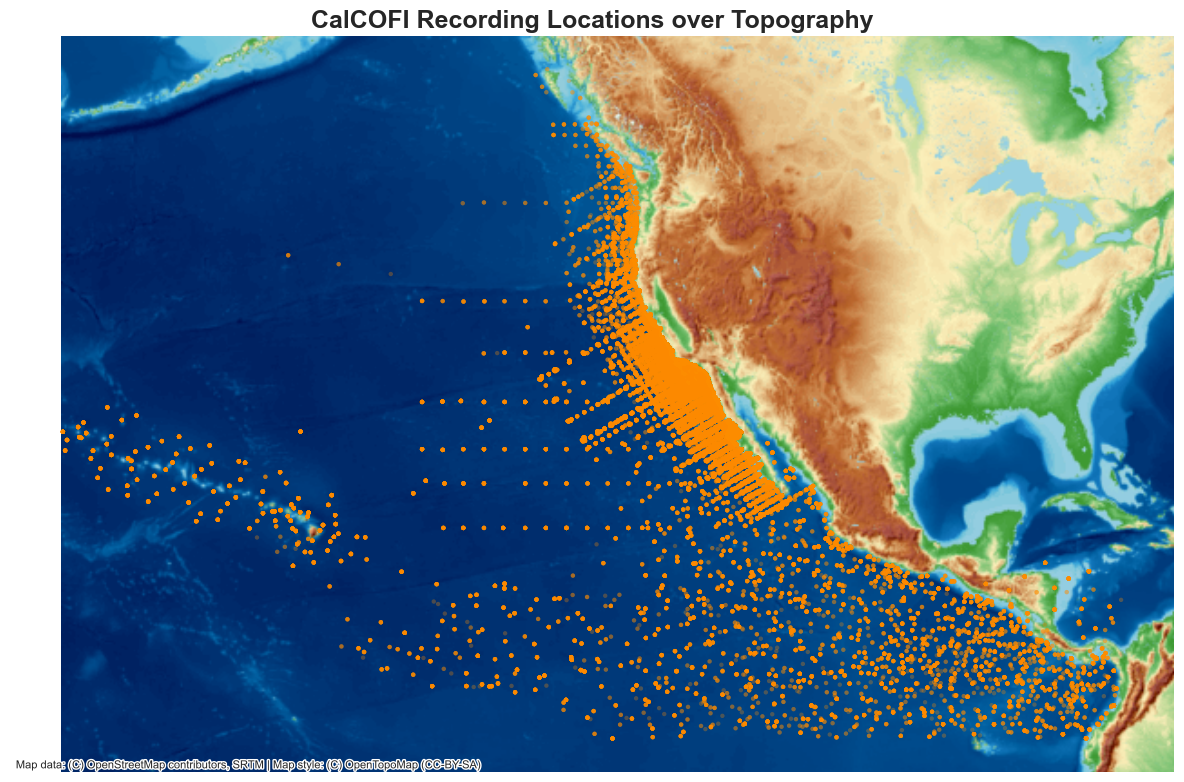

In [19]:
# =========================================================
# VISUALIZATION 1: Geographical Plotting of Cruise Paths
# =========================================================

# 1. Convert our Pandas DataFrame into a GeoDataFrame 
# EPSG:4326 is the standard coordinate reference system for Lat/Lon
gdf = gpd.GeoDataFrame(
    fish_df, 
    geometry=gpd.points_from_xy(fish_df.longitude, fish_df.latitude),
    crs="EPSG:4326"
)

# 2. Convert to Web Mercator (EPSG:3857) 
# Map tile providers (like Contextily) require Web Mercator projection to align properly
gdf_web_mercator = gdf.to_crs(epsg=3857)

# 3. Create the plot
fig, ax = plt.subplots(figsize=(12, 12))

# Plot the points (adjust 'markersize' and 'alpha' depending on how dense your data is)
gdf_web_mercator.plot(ax=ax, markersize=10, color='darkorange', alpha=0.3, edgecolor='none')

# Add the topographic background using Contextily's OpenTopoMap provider
# This will automatically bound itself to the extent of your data (San Diego / SoCal coast)
ctx.add_basemap(ax, source=ctx.providers.OpenTopoMap)

ax.set_title('CalCOFI Recording Locations over Topography', fontsize=18, fontweight='bold')
plt.axis('off') # Hide the raw axis numbers since the map is visual
plt.tight_layout()
plt.show()

Straight lines near the California and Western US coast depict the CalCOFI sampling grid, The program was designed to survey specific perpendicular "lines" and "stations." The goal was to eliminate geographic variables: by visiting the exact same GPS coordinates year after year, scientists could confidently say that any changes in fish larvae numbers were due to actual population/environmental shifts, not just because they sampled a different patch of ocean. 

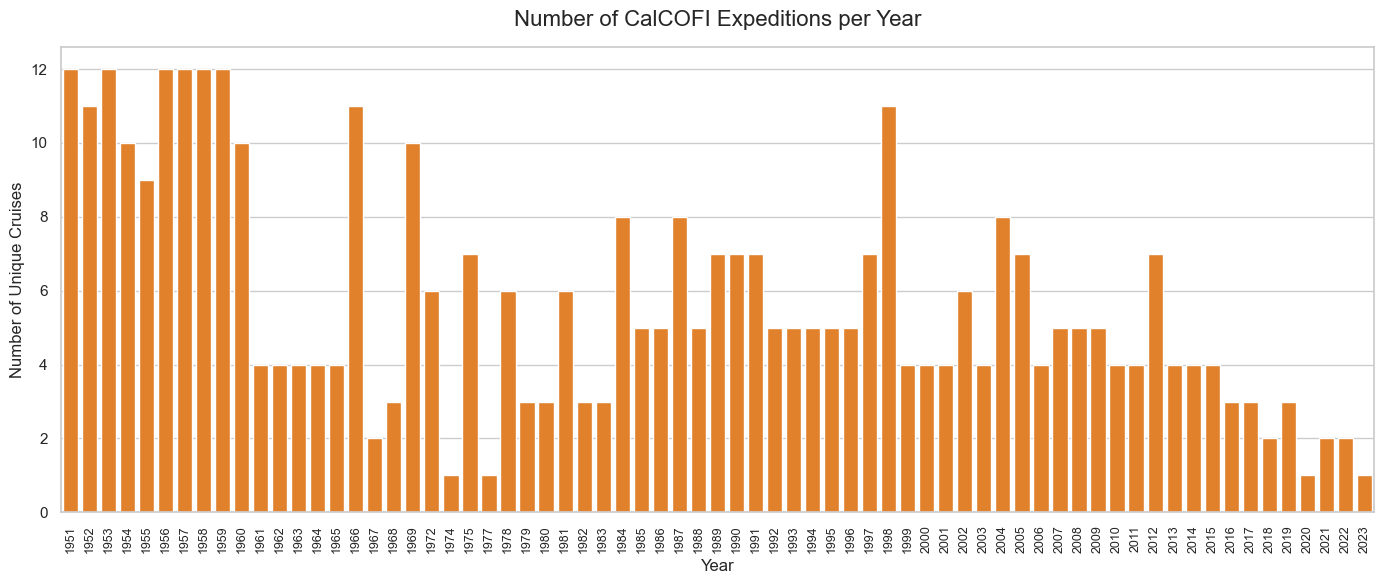

In [12]:
# =========================================================
# PLOT 2: Number of Expeditions Over the Years
# =========================================================
plt.figure(figsize=(14, 6))

# Group by year and count the number of UNIQUE cruises per year
# We use 'nunique()' because one cruise has thousands of rows of fish data
expeditions_per_year = fish_df.groupby('year')['cruise'].nunique().reset_index()
expeditions_per_year.rename(columns={'cruise': 'cruise_count'}, inplace=True)

# Create a bar plot
sns.barplot(
    data=expeditions_per_year, 
    x='year', 
    y='cruise_count', 
    color='#ff7f0e'
)

plt.title('Number of CalCOFI Expeditions per Year', fontsize=16, pad=15)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Unique Cruises', fontsize=12)

# Rotate the x-axis labels so the years are legible
plt.xticks(rotation=90, fontsize=9)
# Show every 2nd year on the x-axis to prevent crowding if needed, 
# but seaborn's default with rotated labels usually handles decades well.

plt.tight_layout()
plt.show()

Original dataset rows: 385733
Core CalCOFI dataset rows: 362576


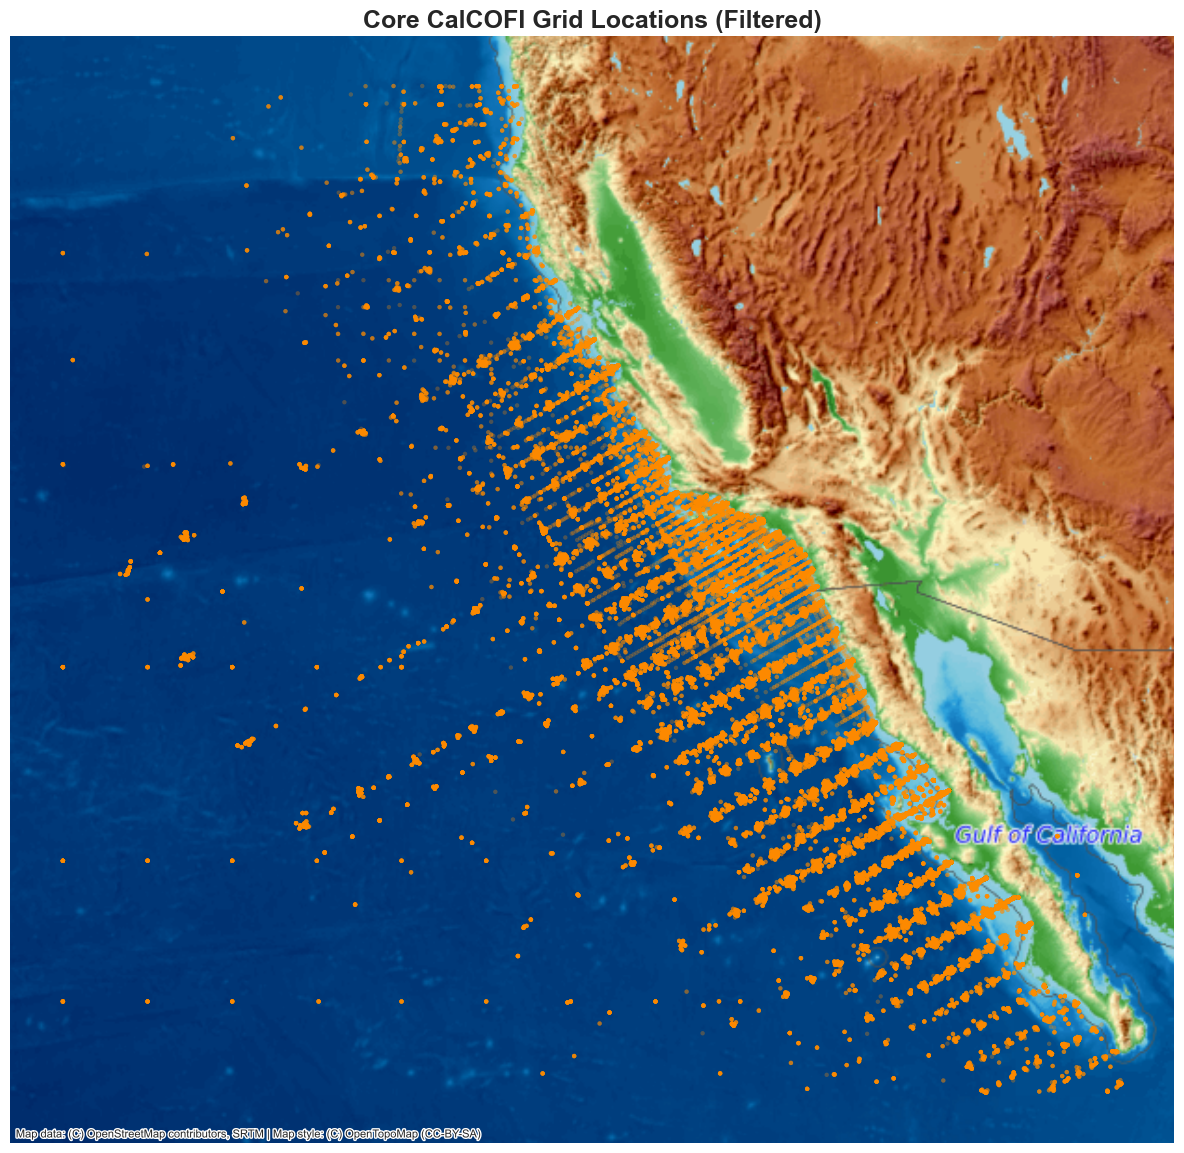

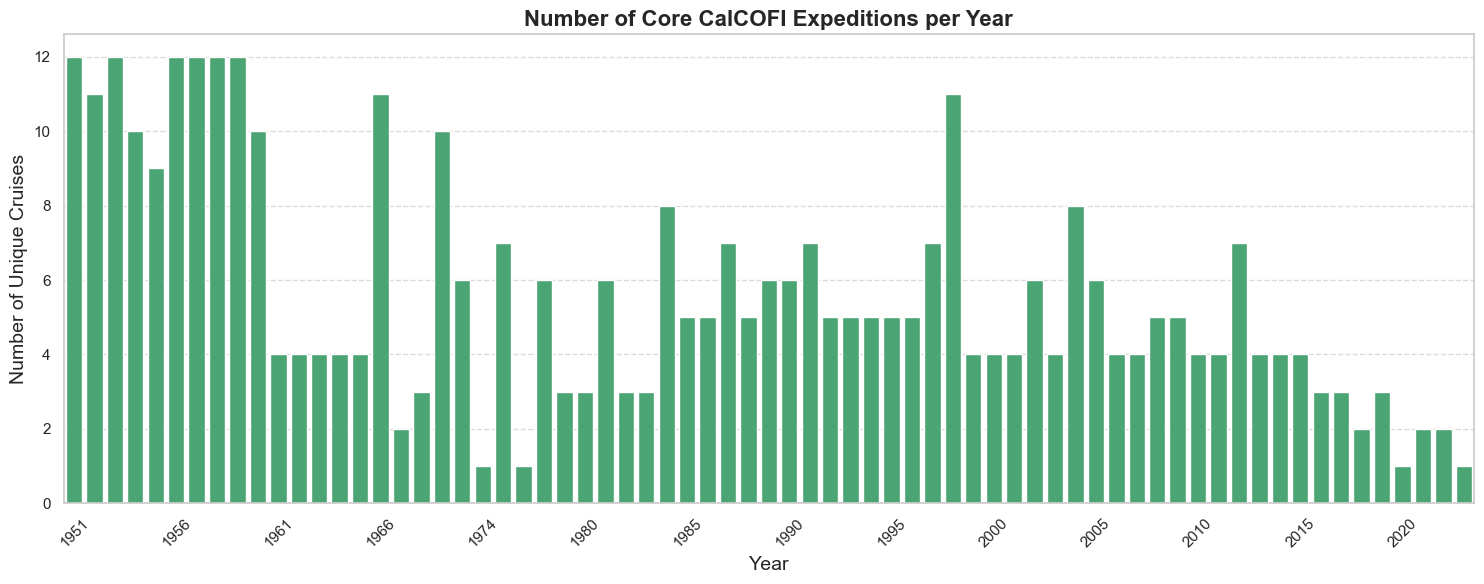

In [20]:
# =========================================================
# 1. FILTERING: Creating the Core CalCOFI Dataset
# =========================================================

# Apply a geographic bounding box around the US West Coast / Baja
# and ensure 'line' and 'station' values exist.
calcofi_core_df = fish_df[
    (fish_df['latitude'] >= 22.0) & (fish_df['latitude'] <= 42.0) & 
    (fish_df['longitude'] >= -135.0) & (fish_df['longitude'] <= -110.0)
].copy()

# Drop rows that don't have an official CalCOFI line/station grid assignment
calcofi_core_df = calcofi_core_df.dropna(subset=['line', 'station'])

print(f"Original dataset rows: {len(fish_df)}")
print(f"Core CalCOFI dataset rows: {len(calcofi_core_df)}")

# =========================================================
# 2. VISUALIZATION 1: Updated Geographical Map
# =========================================================

# Convert our filtered DataFrame into a GeoDataFrame 
gdf_core = gpd.GeoDataFrame(
    calcofi_core_df, 
    geometry=gpd.points_from_xy(calcofi_core_df.longitude, calcofi_core_df.latitude),
    crs="EPSG:4326"
)

# Convert to Web Mercator for the Contextily basemap
gdf_core_web = gdf_core.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(12, 12))

# Plot the filtered points
gdf_core_web.plot(ax=ax, markersize=10, color='darkorange', alpha=0.3, edgecolor='none')

# Add topographic background
ctx.add_basemap(ax, source=ctx.providers.OpenTopoMap)

ax.set_title('Core CalCOFI Grid Locations (Filtered)', fontsize=18, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

# =========================================================
# 3. VISUALIZATION 2: Updated Expeditions per Year
# =========================================================

# Group by Year and count the unique cruises in the FILTERED dataset
expeditions_per_year_core = calcofi_core_df.groupby('year')['cruise'].nunique().reset_index()
expeditions_per_year_core.rename(columns={'cruise': 'num_expeditions'}, inplace=True)

fig, ax = plt.subplots(figsize=(15, 6))
sns.barplot(
    data=expeditions_per_year_core, 
    x='year', 
    y='num_expeditions', 
    color='mediumseagreen', # Changed color to distinguish from the first plot 
    ax=ax
)

# Clean up the x-axis to show every 5th year
plt.xticks(rotation=45)
for ind, label in enumerate(ax.get_xticklabels()):
    if ind % 5 == 0:  
        label.set_visible(True)
    else:
        label.set_visible(False)

ax.set_title('Number of Core CalCOFI Expeditions per Year', fontsize=16, fontweight='bold')
ax.set_xlabel('Year', fontsize=14)
ax.set_ylabel('Number of Unique Cruises', fontsize=14)
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Budget cuts in 60s and 70s caused CalCOFI to reduce total number of voyages, instead had to pivot to doing 1-2 years without many cruises into a year with a lot of cruises. Modern day decline is due to budget cuts, COVID (specifically 2020), and issues with maintanence.